# Defining time segments and plotting PSD

This example demonstrates how to:

- Load size-resolved SMPS data (`Aerosol2D`)
- Plot timeseries
- Define activity periods/segments and mark these in the dataset
- Summarize concentration measures for all of the defined activity segments
- Plot PSD from each activity

First we import the package

In [1]:
import aerosoltools as at

Then we load the SMPS data

In [2]:
filename = r"..\..\tests\data\Sample_SMPS.txt"
SMPS_data = at.Load_SMPS_file(filename);

We then visualiza the dataset via timeseries plot

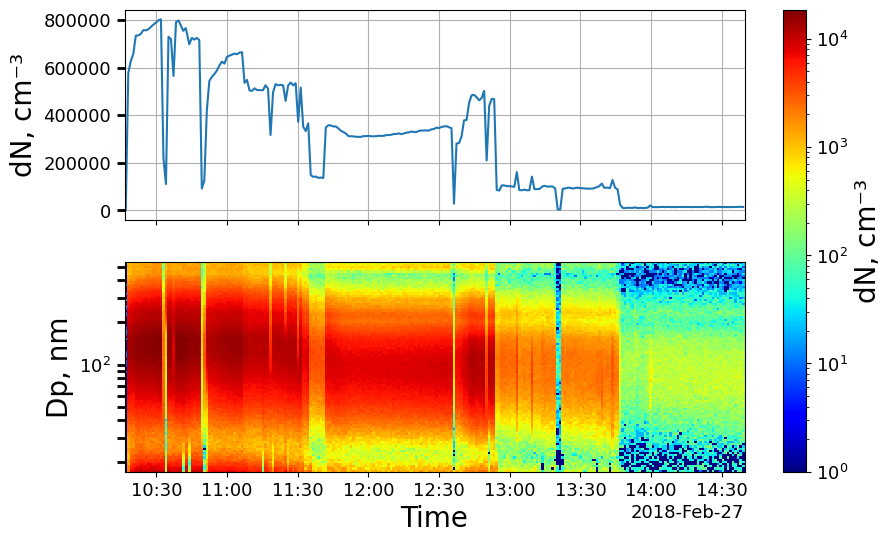

In [3]:
SMPS_data.plot_timeseries(y_3d=(1,0));

We see that there are specific time intervals where the particle number concentration rises. Now we want to pool the data points within some of these times, and categorize them as specific activities e.g. cutting, sanding, or just emission.

In order to do so, we first need to make a dictionary with start and end times of the relevant time periods:

In [4]:
activity_periods = {
    "Emission": [
        ("2018-02-27 10:18:00", "2018-02-27 10:31:00"),
        ("2018-02-27 10:35:00", "2018-02-27 10:48:00"),
        ("2018-02-27 10:52:00", "2018-02-27 11:30:00"),
        ("2018-02-27 12:39:00", "2018-02-27 12:48:00")
    ],
    "Constant phase 1": [
        ("2018-02-27 11:43:00", "2018-02-27 12:35:00")
    ],
    "Constant phase 2": [
        ("2018-02-27 12:55:00", "2018-02-27 13:45:00")
    ],
    "Background": [
        ("2018-02-27 13:48:00", "2018-02-27 14:39:00")
   ]
}

We then mark this activities within the dataset, making a boolean column in the main DataFrame used for indexing the defined activity periods.

In [5]:
SMPS_data.mark_activities(activity_periods)

We can then replot the time_series but now while marking activities:

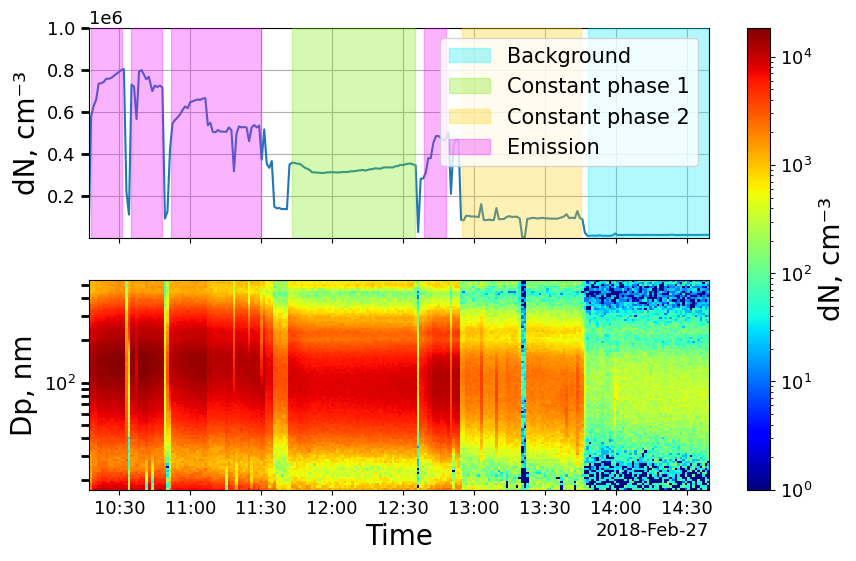

In [6]:
SMPS_data.plot_timeseries(y_3d=(1,0),y_tot = (0,1e6), mark_activities=True);

Finally we can use the summarize function to get statistics of the PNC, PMx levels, total mass, and particle sizes during each time segment.

In [7]:
SMPS_data.summarize_activities();


Summary of aerosol properties (transposed):

+------------------------+-----------+-----------+------------------+------------------+------------+
|                        | All data  | Emission  | Constant phase 1 | Constant phase 2 | Background |
+------------------------+-----------+-----------+------------------+------------------+------------+
|    Duration (HH:MM)    |   04:23   |   01:13   |      00:52       |      00:50       |   00:50    |
|       PNC [cm⁻³]       | 288312.68 | 602466.0  |    327940.95     |     93446.62     |  12901.47  |
|     PNC [cm⁻³] std     | 243453.98 | 123893.66 |     15520.43     |     24034.16     |  1915.46   |
|      PM1 [µg/m³]       |  856.92   |  2118.65  |      673.55      |      191.84      |   27.39    |
|    PM1 [µg/m³] std     |  923.16   |  665.04   |      43.52       |      50.27       |    3.81    |
|     PM2.5 [µg/m³]      |  866.73   |  2141.0   |      683.44      |      194.27      |   27.81    |
|   PM2.5 [µg/m³] std    |  932.68  

We can also plot the PSD of each time segment:

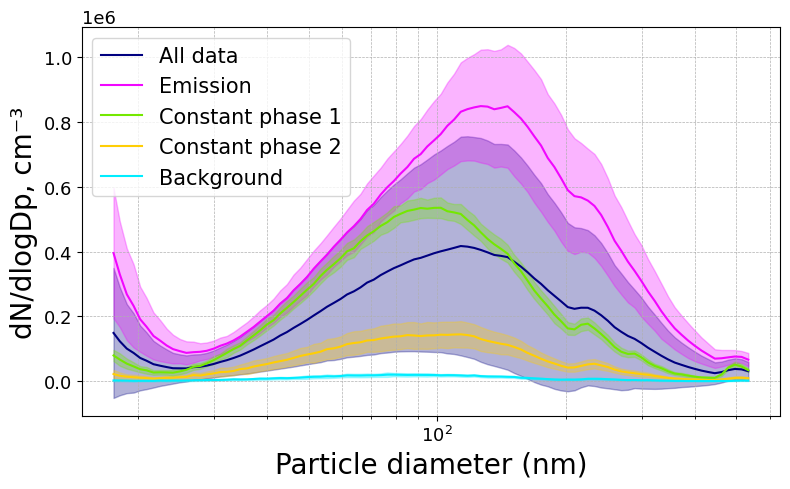

In [8]:
fig,ax = SMPS_data.plot_psd();